# Notebook 02 — Data Integration

**Project:** Carbon Emission Reduction in Data Centres through Smart Scheduling  
**Module:** IS6611 Applied Research in Business Analytics

## Purpose
Run the full data integration pipeline and validate the outputs.

| Step | Input | Output | Module |
|------|-------|--------|--------|
| 1 — Demand | 5 × ORNL `.parquet` | `demand_engineered.csv` | `src.data.demand_processor` |
| 2 — Supply | `supply_all_years.csv` | `supply_engineered.csv` | `src.data.supply_processor` |
| 3 — Integrate | both CSVs | `integrated.csv` | `src.data.integrator` |

> **Runtime note:** Step 1 processes ~4 GB of parquet data.  
> Expect **15–25 minutes** on a standard laptop (800 MB × 5 files, sequential).  
> Steps 2 and 3 take < 1 minute each.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from config.settings import DEMAND_OUTPUT, SUPPLY_OUTPUT, INTEGRATED_OUTPUT
from src.data.demand_processor import process_all_days
from src.data.supply_processor import process_supply
from src.data.integrator       import integrate

sns.set_theme(style='whitegrid', palette='muted')
print('Ready.')

Ready.


---
## Step 1 · Demand Processing
Reads all 5 ORNL parquet files, converts to hourly cluster-level metrics.

In [2]:
# Set force=True to re-process even if the output file exists.
force = False

if DEMAND_OUTPUT.exists() and not force:
    print(f'Loading existing: {DEMAND_OUTPUT.name}')
    demand = pd.read_csv(DEMAND_OUTPUT, parse_dates=['local_hour'])
else:
    print('Processing ORNL parquet files … (this will take ~15–25 min)')
    demand = process_all_days()

print(f'\nDemand shape: {demand.shape}')
demand.head()

Loading existing: demand_engineered.csv

Demand shape: (120, 15)


,local_hour,total_nodes,active_nodes,avg_gpu_power_W,idle_nodes,utilization_rate,cluster_power_kW,active_power_kW,idle_power_kW,active_energy_kWh,shiftable_energy_kWh,shiftable_energy_20p_kWh,shiftable_energy_40p_kWh,snapshot_date,hour_of_day
0,2020-01-19 19:00:00,4626,4090,608.86566,536,0.884,5091.7036,4725.7910,365.912140,4725.7910,1417.7373,945.1582,1890.3164,2020-01-20,19
1,2020-01-19 20:00:00,4626,3981,587.05270,645,0.861,5031.3423,4565.0923,466.249970,4565.0923,1369.5277,913.0185,1826.0370,2020-01-20,20
2,2020-01-19 21:00:00,4626,4560,627.01605,66,0.986,5333.9546,5289.0474,44.907055,5289.0474,1586.7142,1057.8094,2115.6190,2020-01-20,21
3,2020-01-19 22:00:00,4626,4526,614.33057,100,0.978,5229.8677,5159.9937,69.873970,5159.9937,1547.9982,1031.9988,2063.9976,2020-01-20,22
4,2020-01-19 23:00:00,4626,3710,563.65155,916,0.802,4846.7363,4226.0920,620.644400,4226.0920,1267.8276,845.2184,1690.4368,2020-01-20,23


In [3]:
# Validate: should have exactly 24 rows per snapshot day
counts = demand.groupby('snapshot_date').size()
print('Rows per snapshot day:')
print(counts.to_string())
assert (counts == 24).all(), 'Expected 24 hourly rows per day!'

Rows per snapshot day:
snapshot_date
2020-01-20    24
2020-08-20    24
2021-02-20    24
2021-08-10    24
2022-01-20    24


In [4]:
# Demand summary statistics
demand.describe().round(2)

,local_hour,total_nodes,active_nodes,avg_gpu_power_W,idle_nodes,utilization_rate,cluster_power_kW,active_power_kW,idle_power_kW,active_energy_kWh,shiftable_energy_kWh,shiftable_energy_20p_kWh,shiftable_energy_40p_kWh,hour_of_day
count,120,120.00,120.00,120.00,120.00,120.00,120.00,120.00,120.00,120.00,120.00,120.00,120.00,120.00
mean,2021-02-05 02:06:00,4624.88,3179.35,488.12,1445.53,0.69,4944.53,3830.18,1114.35,3830.18,1149.05,766.04,1532.07,11.50
min,2020-01-19 19:00:00,4620.00,58.00,249.36,66.00,0.01,3606.73,69.52,44.91,69.52,20.86,13.90,27.81,0.00
25%,2020-08-20 01:45:00,4626.00,2598.50,410.48,803.75,0.56,4538.09,3366.03,624.34,3366.03,1009.81,673.21,1346.41,5.75
50%,2021-02-20 06:30:00,4626.00,3359.50,476.04,1266.50,0.73,4923.94,3946.03,1008.81,3946.03,1183.81,789.21,1578.41,11.50
75%,2021-08-10 13:15:00,4626.00,3822.25,563.66,2021.50,0.83,5386.36,4598.40,1515.73,4598.40,1379.52,919.68,1839.36,17.25
max,2022-01-20 18:00:00,4626.00,4560.00,749.28,4568.00,0.99,6144.26,5519.76,3735.50,5519.76,1655.93,1103.95,2207.90,23.00
std,NaN,2.25,879.17,103.43,878.14,0.19,562.98,1031.92,673.40,1031.92,309.58,206.38,412.77,6.95


NameError: name 'mticker' is not defined

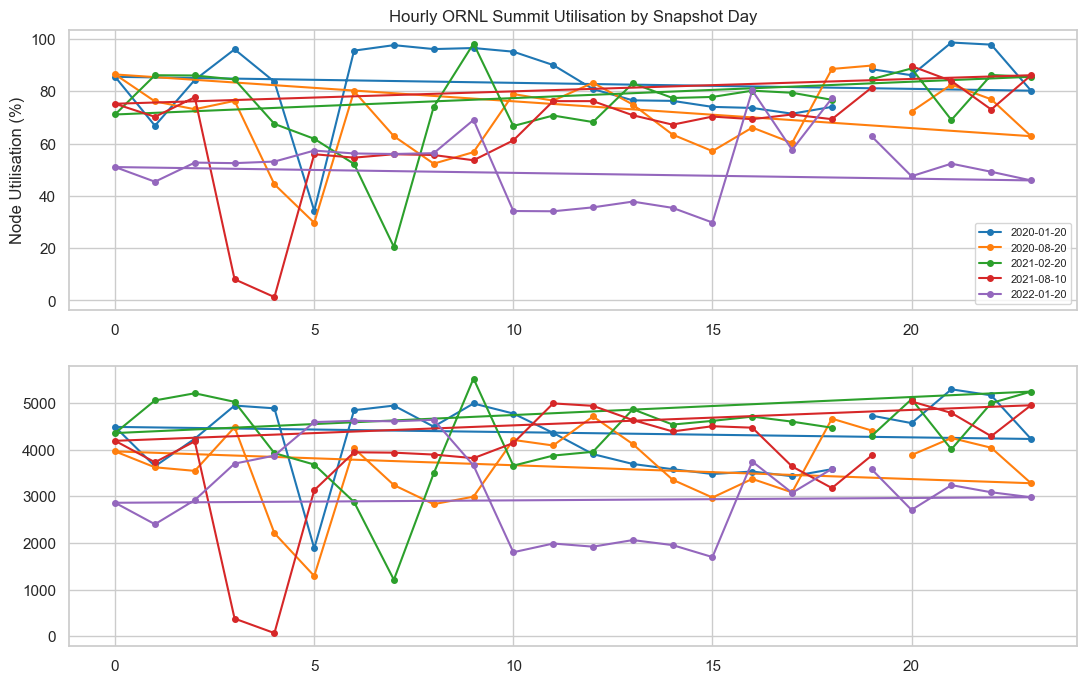

In [5]:
# Plot: hourly cluster utilisation across all snapshot days
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=False)

colors = plt.cm.tab10.colors
for i, (date, grp) in enumerate(demand.groupby('snapshot_date')):
    axes[0].plot(grp['hour_of_day'], grp['utilization_rate'] * 100,
                 marker='o', ms=4, lw=1.5, color=colors[i], label=date)
    axes[1].plot(grp['hour_of_day'], grp['active_power_kW'],
                 marker='o', ms=4, lw=1.5, color=colors[i], label=date)

axes[0].set_ylabel('Node Utilisation (%)')
axes[0].set_title('Hourly ORNL Summit Utilisation by Snapshot Day')
axes[0].legend(loc='lower right', fontsize=8)
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

axes[1].set_ylabel('Active Cluster Power (kW)')
axes[1].set_xlabel('Hour of Day (Eastern)')
axes[1].set_title('Hourly Active Power Draw by Snapshot Day')

for ax in axes:
    ax.set_xticks(range(0, 24, 2))

import matplotlib.ticker as mticker
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data' / 'processed' / 'demand_hourly_profile.png',
            dpi=150, bbox_inches='tight')
plt.show()

---
## Step 2 · Supply Processing
Reads TVA generation-mix CSV, computes carbon intensity for each hour.

In [6]:
if SUPPLY_OUTPUT.exists() and not force:
    print(f'Loading existing: {SUPPLY_OUTPUT.name}')
    supply = pd.read_csv(SUPPLY_OUTPUT, parse_dates=['datetime'])
else:
    supply = process_supply()

print(f'Supply shape: {supply.shape}')
supply[['datetime', 'COL', 'NG', 'NUC', 'WAT', 'SUN', 'WND',
        'total_generation_MWh', 'carbon_intensity_gCO2_per_kWh',
        'low_carbon_share']].head()

Loading existing: supply_engineered.csv
Supply shape: (35064, 27)


,datetime,COL,NG,NUC,WAT,SUN,WND,total_generation_MWh,carbon_intensity_gCO2_per_kWh,low_carbon_share
0,2019-01-01 00:00:00,1672.0,1684.0,8204.0,4751.0,0.0,0.0,16322.0,149.20,0.7937
1,2019-01-01 01:00:00,1689.0,1383.0,8210.0,4730.0,0.0,0.0,16026.0,144.66,0.8074
2,2019-01-01 02:00:00,1725.0,1033.0,8212.0,4381.0,0.0,0.0,15362.0,142.91,0.8198
3,2019-01-01 03:00:00,1747.0,1459.0,8212.0,3352.0,0.0,0.0,14784.0,163.05,0.7822
4,2019-01-01 04:00:00,1712.0,1292.0,8234.0,3000.0,0.0,0.0,14252.0,161.41,0.7882


/var/folders/ll/g56h5zkx6q3g3qh4w_qhb19r0000gn/T/ipykernel_7475/1300892953.py:18: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/ll/g56h5zkx6q3g3qh4w_qhb19r0000gn/T/ipykernel_7475/1300892953.py:19: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig(PROJECT_ROOT / 'data' / 'processed' / 'supply_ci_distribution.png',
/opt/anaconda3/envs/myenv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


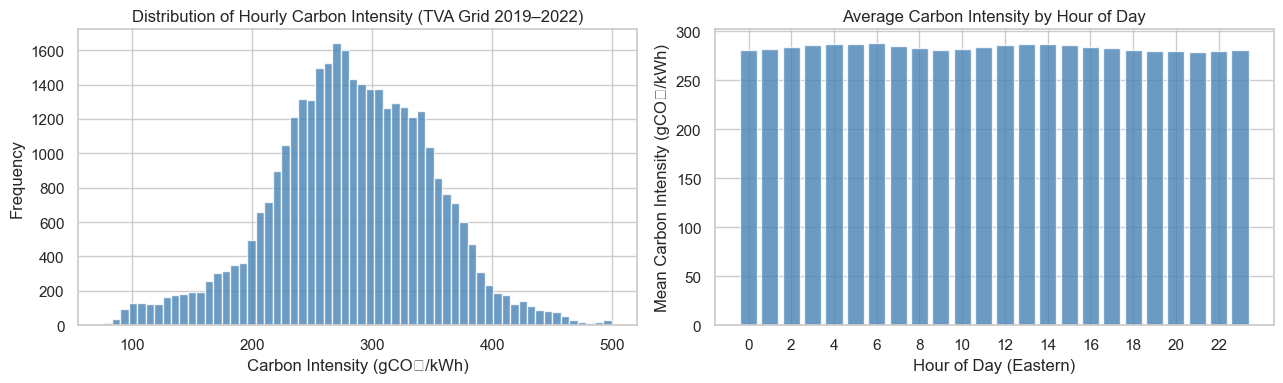

Mean CI       : 283.1 gCO₂/kWh
CI range      : 75.7 – 499.9 gCO₂/kWh
Low-carbon share: 56.3%


In [7]:
# Carbon intensity distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(supply['carbon_intensity_gCO2_per_kWh'].dropna(), bins=60,
             color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_xlabel('Carbon Intensity (gCO₂/kWh)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Hourly Carbon Intensity (TVA Grid 2019–2022)')

# Mean CI by hour of day
ci_by_hour = supply.groupby('hour_of_day')['carbon_intensity_gCO2_per_kWh'].mean()
axes[1].bar(ci_by_hour.index, ci_by_hour.values, color='steelblue', alpha=0.8)
axes[1].set_xlabel('Hour of Day (Eastern)')
axes[1].set_ylabel('Mean Carbon Intensity (gCO₂/kWh)')
axes[1].set_title('Average Carbon Intensity by Hour of Day')
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data' / 'processed' / 'supply_ci_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean CI       : {supply['carbon_intensity_gCO2_per_kWh'].mean():.1f} gCO₂/kWh")
print(f"CI range      : {supply['carbon_intensity_gCO2_per_kWh'].min():.1f} – {supply['carbon_intensity_gCO2_per_kWh'].max():.1f} gCO₂/kWh")
print(f"Low-carbon share: {supply['low_carbon_share'].mean():.1%}")

---
## Step 3 · Integration
Merge demand and supply; compute baseline vs. optimised carbon emissions.

In [8]:
if INTEGRATED_OUTPUT.exists() and not force:
    print(f'Loading existing: {INTEGRATED_OUTPUT.name}')
    integrated = pd.read_csv(INTEGRATED_OUTPUT, parse_dates=['local_hour'])
else:
    integrated = integrate()

print(f'Integrated shape: {integrated.shape}')
integrated[['snapshot_date', 'hour_of_day', 'active_energy_kWh', 'shiftable_energy_kWh',
            'carbon_intensity_gCO2_per_kWh', 'day_min_ci',
            'baseline_carbon_kg', 'optimized_carbon_kg', 'carbon_saved_kg',
            'carbon_reduction_pct']].head(10)

Loading existing: integrated.csv
Integrated shape: (120, 47)


,snapshot_date,hour_of_day,active_energy_kWh,shiftable_energy_kWh,carbon_intensity_gCO2_per_kWh,day_min_ci,baseline_carbon_kg,optimized_carbon_kg,carbon_saved_kg,carbon_reduction_pct
0,2020-01-20,19,4725.7910,1417.7373,216.63,178.43,1023.748,969.591,54.158,5.29
1,2020-01-20,20,4565.0923,1369.5277,212.67,178.43,970.858,923.966,46.893,4.83
2,2020-01-20,21,5289.0474,1586.7142,213.61,178.43,1129.793,1073.973,55.821,4.94
3,2020-01-20,22,5159.9937,1547.9982,218.18,178.43,1125.807,1064.274,61.533,5.47
4,2020-01-20,23,4226.0920,1267.8276,234.71,178.43,991.906,920.553,71.353,7.19
5,2020-01-20,0,4483.7026,1345.1108,238.83,238.83,1070.843,1070.843,0.000,0.00
6,2020-01-20,1,3641.3510,1092.4054,248.19,238.83,903.747,893.522,10.225,1.13
7,2020-01-20,2,4231.0460,1269.3138,252.48,238.83,1068.254,1050.928,17.326,1.62
8,2020-01-20,3,4940.5110,1482.1534,254.01,238.83,1254.939,1232.440,22.499,1.79
9,2020-01-20,4,4882.0996,1464.6299,261.36,238.83,1275.986,1242.987,32.998,2.59


In [9]:
# Per-day carbon summary
day_summary = integrated.groupby('snapshot_date').agg(
    total_active_kWh        = ('active_energy_kWh',     'sum'),
    total_shiftable_kWh     = ('shiftable_energy_kWh',  'sum'),
    baseline_carbon_kg      = ('baseline_carbon_kg',    'sum'),
    optimized_carbon_kg     = ('optimized_carbon_kg',   'sum'),
    carbon_saved_kg         = ('carbon_saved_kg',       'sum'),
    carbon_reduction_pct    = ('carbon_reduction_pct',  'mean'),
).round(2)

print('\nPer-day carbon summary (30% flexibility assumption):')
display(day_summary)


Per-day carbon summary (30% flexibility assumption):


,total_active_kWh,total_shiftable_kWh,baseline_carbon_kg,optimized_carbon_kg,carbon_saved_kg,carbon_reduction_pct
snapshot_date,,,,,,
2020-01-20,101590.32,30477.10,26775.62,25587.52,1188.11,4.41
2020-08-20,86585.48,25975.65,26878.73,26406.26,472.48,1.62
2021-02-20,103184.63,30955.39,35783.77,34767.39,1016.38,2.80
2021-08-10,93018.98,27905.69,34294.87,33248.07,1046.79,3.04
2022-01-20,75242.47,22572.74,22074.55,21790.68,283.88,1.26


/var/folders/ll/g56h5zkx6q3g3qh4w_qhb19r0000gn/T/ipykernel_7475/60141892.py:15: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/ll/g56h5zkx6q3g3qh4w_qhb19r0000gn/T/ipykernel_7475/60141892.py:16: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig(PROJECT_ROOT / 'data' / 'processed' / 'sensitivity_analysis.png',
/opt/anaconda3/envs/myenv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


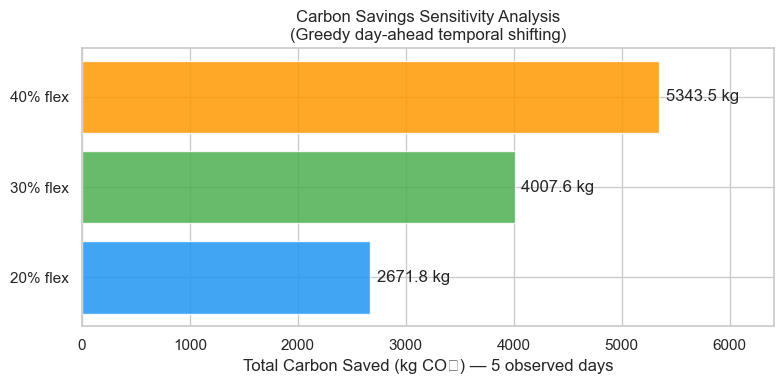

In [10]:
# Sensitivity analysis
scenarios = {
    '20% flex': integrated['carbon_saved_20p_gCO2'].sum() / 1000,
    '30% flex': integrated['carbon_saved_gCO2'].sum()    / 1000,
    '40% flex': integrated['carbon_saved_40p_gCO2'].sum() / 1000,
}

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(list(scenarios.keys()), list(scenarios.values()),
               color=['#2196F3', '#4CAF50', '#FF9800'], alpha=0.85)
ax.bar_label(bars, fmt='%.1f kg', padding=5)
ax.set_xlabel('Total Carbon Saved (kg CO₂) — 5 observed days')
ax.set_title('Carbon Savings Sensitivity Analysis\n(Greedy day-ahead temporal shifting)')
ax.set_xlim(0, max(scenarios.values()) * 1.2)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data' / 'processed' / 'sensitivity_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()

/var/folders/ll/g56h5zkx6q3g3qh4w_qhb19r0000gn/T/ipykernel_7475/368507694.py:26: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/ll/g56h5zkx6q3g3qh4w_qhb19r0000gn/T/ipykernel_7475/368507694.py:27: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig(PROJECT_ROOT / 'data' / 'processed' / f'ci_vs_shiftable_{sample_day}.png',


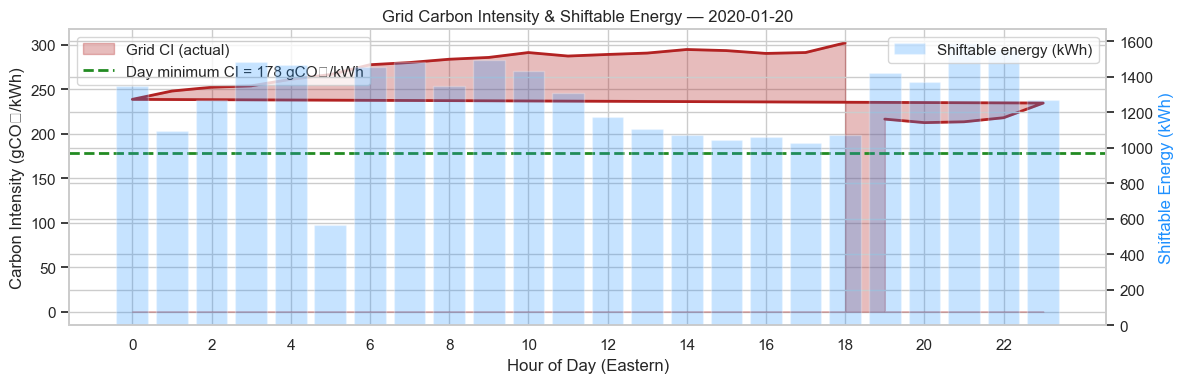

In [11]:
# Baseline vs. optimised hourly CI — overlay for one snapshot day
sample_day = integrated['snapshot_date'].iloc[0]
day_data = integrated[integrated['snapshot_date'] == sample_day].copy()

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(day_data['hour_of_day'], day_data['carbon_intensity_gCO2_per_kWh'],
                alpha=0.3, color='firebrick', label='Grid CI (actual)')
ax.plot(day_data['hour_of_day'], day_data['carbon_intensity_gCO2_per_kWh'],
        color='firebrick', lw=2)
ax.axhline(day_data['day_min_ci'].iloc[0], color='forestgreen', lw=2, linestyle='--',
           label=f"Day minimum CI = {day_data['day_min_ci'].iloc[0]:.0f} gCO₂/kWh")

# Shade the shiftable energy as stacked bars
ax2 = ax.twinx()
ax2.bar(day_data['hour_of_day'], day_data['shiftable_energy_kWh'],
        alpha=0.25, color='dodgerblue', label='Shiftable energy (kWh)')
ax2.set_ylabel('Shiftable Energy (kWh)', color='dodgerblue')

ax.set_xlabel('Hour of Day (Eastern)')
ax.set_ylabel('Carbon Intensity (gCO₂/kWh)')
ax.set_title(f'Grid Carbon Intensity & Shiftable Energy — {sample_day}')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')
ax.set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data' / 'processed' / f'ci_vs_shiftable_{sample_day}.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Annualised projection summary
annual_30 = integrated['projected_annual_saving_tCO2'].iloc[0]
annual_20 = integrated['projected_annual_saving_20p_tCO2'].iloc[0]
annual_40 = integrated['projected_annual_saving_40p_tCO2'].iloc[0]

print('=' * 55)
print('  Projected Annual Carbon Savings (ORNL Summit)')
print('  (extrapolated from 5 snapshot days × 365)')
print('=' * 55)
print(f'  20% flexibility : {annual_20:>8.1f} tCO₂ / year')
print(f'  30% flexibility : {annual_30:>8.1f} tCO₂ / year  ← central estimate')
print(f'  40% flexibility : {annual_40:>8.1f} tCO₂ / year')
print('=' * 55)
print('  Note: These are projections, not measured figures.')
print('  The model assumes greedy day-ahead temporal shifting.')

  Projected Annual Carbon Savings (ORNL Summit)
  (extrapolated from 5 snapshot days × 365)
  20% flexibility :    195.0 tCO₂ / year
  30% flexibility :    292.6 tCO₂ / year  ← central estimate
  40% flexibility :    390.1 tCO₂ / year
  Note: These are projections, not measured figures.
  The model assumes greedy day-ahead temporal shifting.
